In [1]:
!pip install -q langchain langchain-groq langchain-community langgraph

## Setting up Groq for LLM Inference

**💡What is Groq?**

A platform that serves LLMs and provides access to OpenSource models in their freetier

---

**💡How to access models on Groq?**
 1. Visit : https://console.groq.com/keys
 2. Create an account using your email ID
 3. Click on the "Create API Key" button and enter a name for the key (we are using "CB_LangChain"
 4. Copy the generated key and paste it some where save
 5. Run the code below and paste the groq API Key in the text box

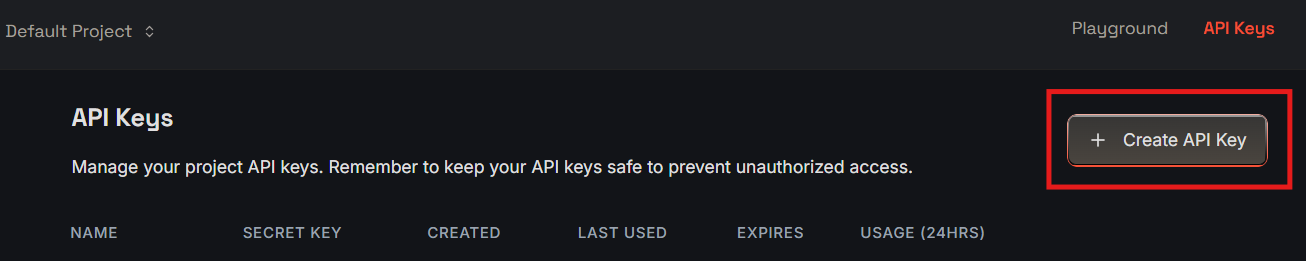

In [2]:
import getpass
import os

if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your Groq API key: ")

In [3]:
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="openai/gpt-oss-20b",
    temperature=0,
    max_tokens=None,
    reasoning_format="parsed",
    timeout=None,
    max_retries=2,
)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### **Adding Tools to our Model**

Along with text generation, many models also support:
- Function/Tool Calling
- Structured Output
- Multimodality
- Reasoning

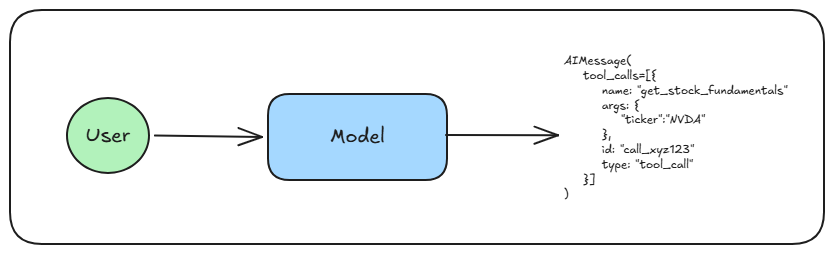

In [4]:
!pip install -q yfinance

In [5]:
import yfinance as yf
from langchain.tools import tool

@tool
def get_stock_fundamentals(ticker: str) -> str:
    """Get current stock price, P/E ratio, market cap, and revenue growth for a ticker."""
    stock = yf.Ticker(ticker)
    info = stock.info
    return {
        "price": info.get("currentPrice"),
        "pe_ratio": info.get("trailingPE"),
        "market_cap": info.get("marketCap"),
        "revenue_growth": info.get("revenueGrowth"),
        "52w_high": info.get("fiftyTwoWeekHigh"),
        "52w_low": info.get("fiftyTwoWeekLow"),
    }

In [8]:
tool_augmented_model = llm.bind_tools([get_stock_fundamentals])

response = tool_augmented_model.invoke("How is Jensen Huang's chip company doing financially")
print(response)
print(f"{500*'='}\n\n")

for tool_call in response.tool_calls:
    print(f"Tool: {tool_call['name']}")
    print(f"Args: {tool_call['args']}")
    tool_result = get_stock_fundamentals.invoke(tool_call)
    print(tool_result.content)

content='' additional_kwargs={'reasoning_content': 'The user asks: "How is Jensen Huang\'s chip company doing financially". Jensen Huang is the CEO of NVIDIA. They want financial performance. We can provide recent financial metrics: revenue, net income, EPS, growth, etc. We can also mention recent quarterly results, guidance, market cap, etc. We can use the function get_stock_fundamentals for NVIDIA ticker NVDA. Let\'s call that.', 'tool_calls': [{'id': 'fc_aac392fb-9ab9-465f-85c3-646423ec64d5', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]} response_metadata={'token_usage': {'completion_tokens': 111, 'prompt_tokens': 145, 'total_tokens': 256, 'completion_time': 0.121757704, 'completion_tokens_details': {'reasoning_tokens': 83}, 'prompt_time': 0.007935807, 'prompt_tokens_details': None, 'queue_time': 0.003117601, 'total_time': 0.129693511}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_728f7c3b5b', 'service_tier':

### **Building Our First Agent**

**_What are we building?_**

A finance research analyst agent that can query stock fundamentals, search through web, reason and help us make financial decisions.

We are going to use the `create_agent` function by langchain that will enable us to build our finance agent without writing tons of code.

REVISION:

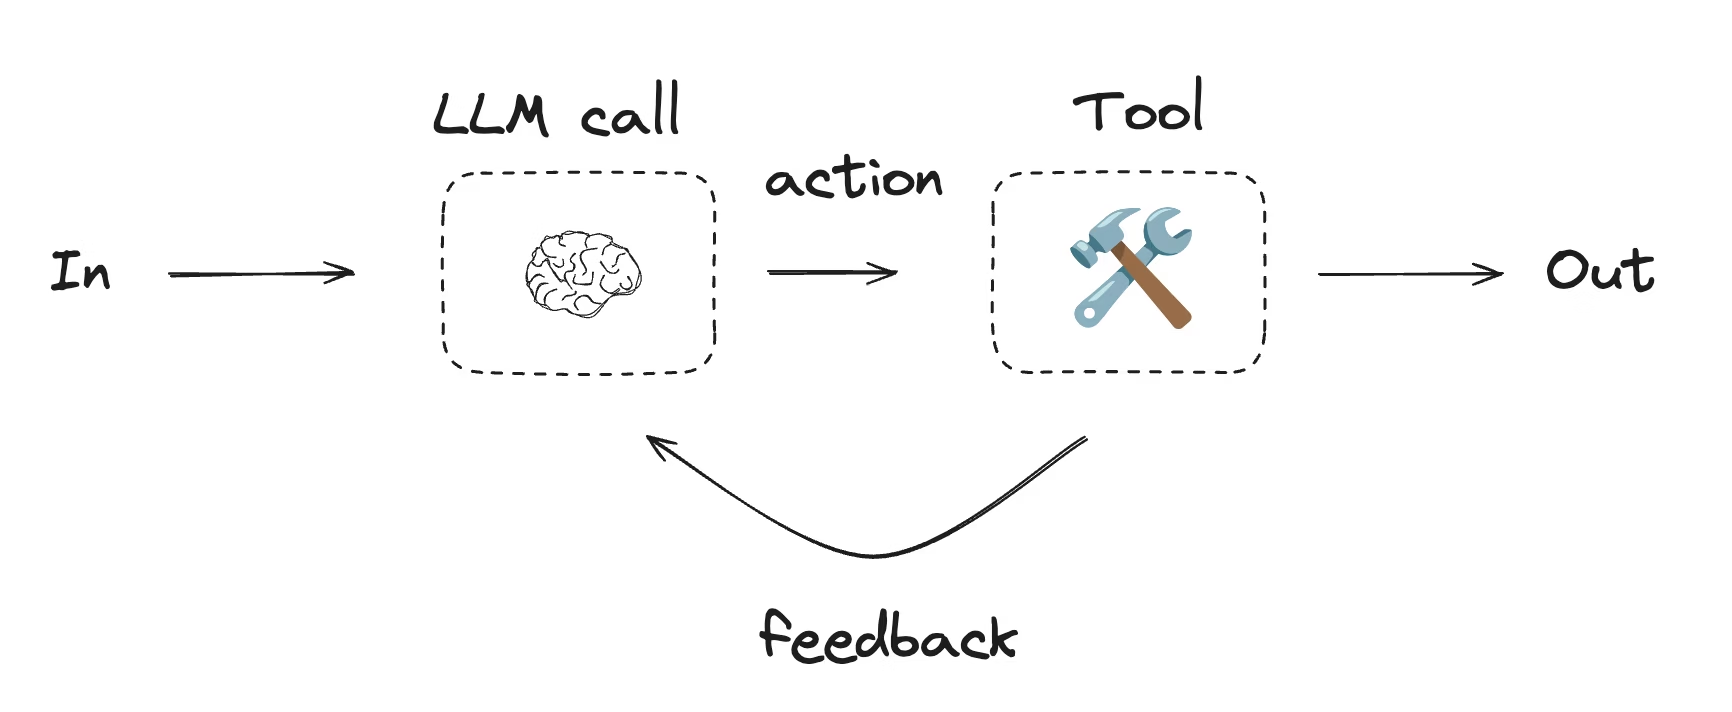


What actions should our Analyst be able to take?

- Search Google & Yahoo news
- Access Yahoo Finance API to get stock fundamentals
- Acesss Wikipedia

In [9]:
!pip install -q wikipedia langchain-community google-search-results

### **SerpAPI**

Allows us to query through google search.

**How to access the API KEY?**

1. Go to https://serpapi.com/dashboard
2. Login with email or Google
3. Get access to the dashboad and click on `API Key`
4. Copy it somewhere safe
5. Paste it in the text box

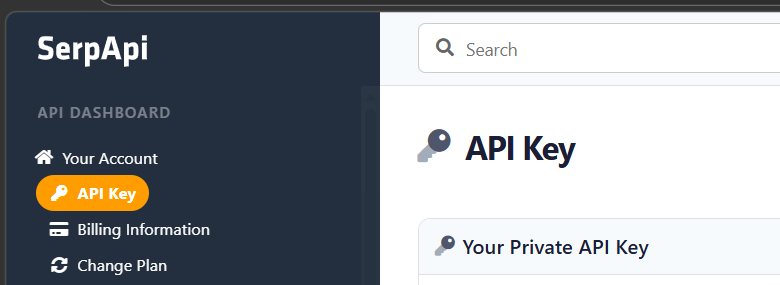

In [11]:
if "SERPAPI_API_KEY" not in os.environ:
    os.environ["SERPAPI_API_KEY"] = getpass.getpass("Enter your SerpAPI API key: ")

In [12]:
from langchain_community.utilities import SerpAPIWrapper

serp = SerpAPIWrapper(
    serpapi_api_key=os.getenv("SERPAPI_API_KEY"),
    params={
        "tbm": "nws",     # Search in Google News
        "tbs": "qdr:d",   # Past day (24 hours)
    },
)

@tool
def search_news(query: str) -> str:
    """
    Search last-24h Google News via SerpAPI.
    Returns news results with URLs.
    """
    return serp.run(query)

In [13]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_community.tools.yahoo_finance_news import YahooFinanceNewsTool


tools = [
    get_stock_fundamentals,
    YahooFinanceNewsTool(),
    WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper()),
    search_news
]

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [14]:
from langchain.agents import create_agent


SYSTEM_PROMPT = """
You are FinBot, an expert equity research analyst with deep knowledge of financial markets,
valuation methodologies, and macroeconomic trends.

## Task
Given a stock ticker or company name, produce a concise, structured analyst brief that helps users evaluate the investment. Do not give buy/sell advice. Present data-driven signals only.

## Rules
1. Gather data before analysis. Never rely on memory for numbers.
2. If a tool fails or returns empty data, state it and proceed.
3. Never fabricate prices, ratios, or news.
4. Always follow the output format.
5. Flag notable risks or red flags.

## Output Format

**[TICKER] — Analyst Brief**
- 📊 **Fundamentals:** price, P/E, market cap, revenue growth (one line)
- 📈 **Valuation Signal:** OVERVALUED / FAIRLY VALUED / UNDERVALUED + reason
- 📰 **News Sentiment:** bullish / neutral / bearish + key headline
- ⚠️ **Key Risks:** 1–2 bullets
- 🧭 **Outlook:** 1–2 sentence synthesis, no advice
"""

my_finance_agent = create_agent(
    model= llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT
)

In [15]:
agent_trace = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick analyst brief on NVDA. Is now a good time to buy?"}]}
)

agent_trace

{'messages': [HumanMessage(content='Give me a quick analyst brief on NVDA. Is now a good time to buy?', additional_kwargs={}, response_metadata={}, id='aa7025c8-61cf-4366-84c7-9fcded050f22'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to produce analyst brief for NVDA. Must gather data: price, P/E, market cap, revenue growth. Use get_stock_fundamentals. Also news sentiment: use yahoo_finance_news or search_news. Let's call get_stock_fundamentals for NVDA.", 'tool_calls': [{'id': 'fc_c691c740-9c9e-4a50-9805-b3fc2c7c3a51', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 87, 'prompt_tokens': 540, 'total_tokens': 627, 'completion_time': 0.094146097, 'completion_tokens_details': {'reasoning_tokens': 59}, 'prompt_time': 0.032233029, 'prompt_tokens_details': None, 'queue_time': 0.475547649, 'total_time': 0.126379126}, 'model_name': 'openai/gpt-oss-20b'

In [16]:
print(agent_trace["messages"][-1].content)

**NVDA — Analyst Brief**  
- 📊 **Fundamentals:** $172.70, P/E ≈ 35.2, market cap ≈ $4.20 T, revenue growth ≈ 73.2% YoY  
- 📈 **Valuation Signal:** FAIRLY VALUED – the P/E is high for a mature tech firm but aligns with its strong 73% revenue growth and near‑peak 52‑week high; price is ~18% below the 52‑week high, suggesting modest upside potential.  
- 📰 **News Sentiment:** bullish – recent analyst upgrades (New Street Research, Zacks) and AI‑related product announcements are driving positive coverage.  
- ⚠️ **Key Risks:**  
  1. Intense competition from AMD, Intel, and emerging AI‑chip startups could erode market share.  
  2. Regulatory scrutiny over AI and semiconductor supply chains may impose constraints or costs.  
- 🧭 **Outlook:** NVDA remains a high‑growth play in the AI and data‑center space, supported by robust revenue expansion and product pipeline. However, valuation remains near the upper end of the spectrum, and competitive or macro‑economic headwinds could temper upside.

In [17]:
agent_repsp_2 = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Now compare it with AMD"}]}
)

In [18]:
print(agent_repsp_2["messages"][-1].content)

**AMD — Analyst Brief**  
- 📊 **Fundamentals:** $201.33, P/E ≈ 76.8, market cap ≈ $328 B, revenue growth ≈ 34.1% YoY  
- 📈 **Valuation Signal:** OVERVALUED – P/E far above semiconductor peers (≈ 30–40) and reflects a premium for AI‑related growth that may not materialize at current rates.  
- 📰 **News Sentiment:** bearish – recent 3 % drop amid sector pressure and rising competition from NVIDIA and Broadcom.  
- ⚠️ **Key Risks:**  
  1. Intensifying competition and margin compression in the CPU market.  
  2. Potential slowdown in AI‑driven demand if macro‑economic conditions weaken.  
- 🧭 **Outlook:** AMD continues to post strong revenue growth, but its valuation premium is under pressure from sector dynamics. Performance will hinge on sustaining high‑margin product launches and navigating competitive headwinds.


### **Short Term Memory:**
Memory for individual chat session. It tracks the ongoing conversation by maintaining message history within a session.

### **Long Term Memory:**
It's user specific memory and application data across session. It can be recalled at any time and in any thread.


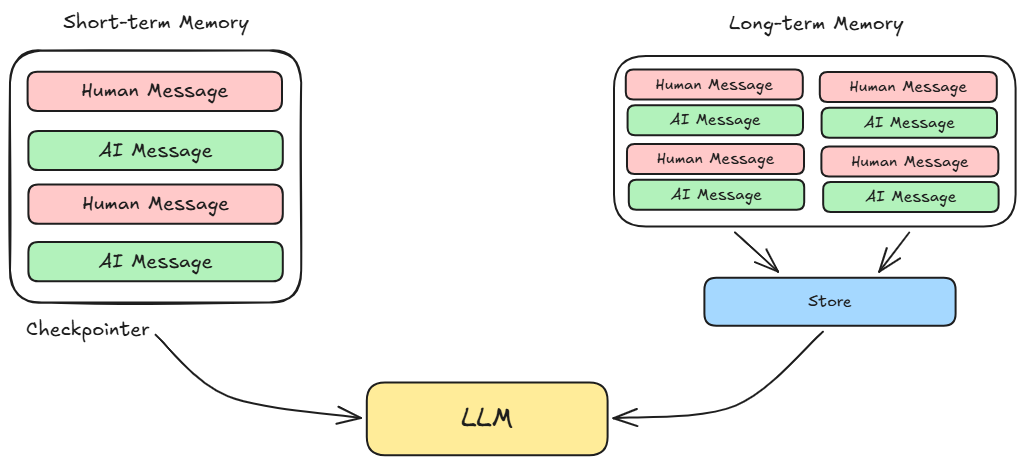

In [19]:
from langgraph.checkpoint.memory import InMemorySaver

my_finance_agent = create_agent(
    model= llm,
    tools=tools,
    system_prompt=SYSTEM_PROMPT,
    checkpointer=InMemorySaver()
)

In [20]:
config = {"configurable": {"thread_id": "user-alice-session-1"}}

In [25]:
my_fin_agent_rep  = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick brief on NVDA"}]},
    config
)
print(my_fin_agent_rep["messages"][-1].content)

**NVDA — Analyst Brief**  
- 📊 **Fundamentals:** $172.70, P/E 35.2, Market Cap $4.20 T, Revenue growth 73.2% YoY  
- 📈 **Valuation Signal:** FAIRLY VALUED – premium P/E justified by strong AI‑chip demand and high revenue growth, but still above the semiconductor average.  
- 📰 **News Sentiment:** bullish – New Street Research added NVDA to its 2026 “Best Ideas” list and analysts are raising earnings outlooks.  
- ⚠️ **Key Risks:**  
  1. Regulatory scrutiny on AI technology and data usage could impact product demand.  
  2. Intense competition from other GPU and AI‑accelerator makers may erode margins.  
- 🧭 **Outlook:** NVDA continues to benefit from the AI boom, driving robust revenue growth, but its valuation premium reflects expectations of sustained demand. The company’s competitive moat and product pipeline support a positive trajectory, tempered by regulatory and competitive headwinds.


In [26]:
my_fin_agent_rep2 = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "How does it compare to AMD on valuation?"}]},
    config
)

print(my_fin_agent_rep2["messages"][-1].content)

**NVDA vs. AMD – Valuation Comparison**

| Metric | NVDA | AMD |
|--------|------|-----|
| **Price** | $172.70 | $201.33 |
| **P/E Ratio** | 35.2 | 76.8 |
| **Market Cap** | $4.20 T | $328 B |
| **Revenue Growth (YoY)** | 73.2% | 34.1% |
| **Valuation Signal** | Fairly valued (growth‑justified premium) | Overvalued (P/E > double NVDA, slower growth) |

**Bottom line:** NVDA trades at a lower price‑to‑earnings multiple and enjoys higher revenue acceleration, making its valuation more aligned with its growth trajectory compared to AMD.


In [27]:
my_fin_agent_rep3 = my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Given both, which has better growth prospects?"}]},
    config
)

print(my_fin_agent_rep3["messages"][-1].content)

**Growth Prospects – NVDA vs. AMD**

- **Revenue Momentum:** NVDA’s YoY revenue growth (~73%) is more than double AMD’s (~34%).
- **Product Pipeline:** NVDA’s AI‑accelerator releases (Hopper GPUs, AI‑agent toolkits) and strong data‑center demand support continued top‑line acceleration.
- **Competitive Landscape:** AMD’s growth is more tied to CPU/graphics cycles and faces margin pressure from price wars, limiting rapid expansion.

**Verdict:** NVDA shows stronger, more consistent growth prospects than AMD.


### **Persistent memory Storage: Sqlite**

Use Sqlite to store messages.

In [31]:
!pip install langgraph-checkpoint-sqlite

In [40]:
import sqlite3
from langgraph.checkpoint.sqlite import SqliteSaver

conn = sqlite3.connect("finance_agent.db", check_same_thread=False)
checkpointer = SqliteSaver(conn)

my_finance_agent_persistent = create_agent(llm,
                                           tools=tools,
                                           system_prompt=SYSTEM_PROMPT,
                                           checkpointer=checkpointer)

In [41]:
config = {"configurable": {"thread_id": "user-alice-session-1"}}

In [42]:
my_finance_agent_persistent.invoke(
    {"messages": [{"role": "user", "content": "Give me a quick brief on NVDA"}]},
    config
)

{'messages': [HumanMessage(content='Give me a quick brief on NVDA', additional_kwargs={}, response_metadata={}, id='0037b20c-4aeb-4eb1-9992-f526a7112ee1'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to fetch fundamentals for NVDA. Use get_stock_fundamentals. Then news sentiment: use yahoo_finance_news or search_news. Let's get fundamentals.", 'tool_calls': [{'id': 'fc_3d7fb02b-2f4a-460f-9077-170b6621a2ee', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 530, 'total_tokens': 593, 'completion_time': 0.069233136, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.005636177, 'prompt_tokens_details': {'cached_tokens': 512}, 'queue_time': 0.440983871, 'total_time': 0.074869313}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_e2cb7a84ec', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls'

In [39]:
my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "How does it compare to AMD on valuation?"}]},
    config
)

{'messages': [HumanMessage(content='Give me a quick brief on NVDA', additional_kwargs={}, response_metadata={}, id='ff1bf1c7-3196-44a4-a8dc-2c421d3e5c53'),
  AIMessage(content='', additional_kwargs={'reasoning_content': "We need to fetch fundamentals for NVDA. Use get_stock_fundamentals. Then news sentiment: use yahoo_finance_news or search_news. Let's get fundamentals.", 'tool_calls': [{'id': 'fc_f277d5cf-3c97-4e12-83d0-7608fe39aad1', 'function': {'arguments': '{"ticker":"NVDA"}', 'name': 'get_stock_fundamentals'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 63, 'prompt_tokens': 530, 'total_tokens': 593, 'completion_time': 0.079818736, 'completion_tokens_details': {'reasoning_tokens': 35}, 'prompt_time': 0.026263375, 'prompt_tokens_details': None, 'queue_time': 0.003161585, 'total_time': 0.106082111}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_334cc21c60', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None

In [ ]:
my_finance_agent.invoke(
    {"messages": [{"role": "user", "content": "Given both, which has better growth prospects?"}]},
    config
)